<a href="https://colab.research.google.com/github/Kainoama/DSS-Team-15-Project/blob/main/Project_Labs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
# File path (replace with your downloaded CSV path)
file_path = "finance.csv"

# 1. Load the dataset
df = pd.read_csv(file_path, low_memory=False)

In [ ]:
df.head()

,asofdate,program,l2locid,borrname,borrstreet,borrcity,borrstate,borrzip,bankname,bankfdicnumber,...,businesstype,businessage,loanstatus,paidinfulldate,chargeoffdate,grosschargeoffamount,revolverstatus,jobssupported,collateralind,soldsecmrktind
0,12/31/2025,7A,507814.0,Plaza Drive Investments LLC,36223 PLAZA DR,CATHEDRAL CITY,CA,92234,"VelocitySBA, LLC",NaN,...,CORPORATION,Existing or more than 2 years old,EXEMPT,NaN,NaN,0.0,0,3,Y,Y
1,12/31/2025,7A,33850.0,Green Mountain Corporation,19301 S Santa Fe Ave,COMPTON,CA,90221,Comerica Bank,983.0,...,CORPORATION,Existing or more than 2 years old,PIF,10/31/2022,NaN,0.0,1,0,Y,NaN
2,12/31/2025,7A,112407.0,Robert D. Thompson and Lilia A. Garcia,8605 Sovereign Row,Dallas,TX,75247,Enterprise Bank & Trust,27237.0,...,CORPORATION,Existing or more than 2 years old,PIF,3/31/2023,NaN,0.0,0,4,Y,Y
3,12/31/2025,7A,85712.0,FordPowerSolutions LLC,520 SWEETWATER BRIDGE CIR,DOUGLASVILLE,GA,30134,United Midwest Savings Bank National Association,32441.0,...,CORPORATION,"Startup, Loan Funds will Open Business",EXEMPT,NaN,NaN,0.0,0,8,Y,Y
4,12/31/2025,7A,317954.0,Link Rec of Minong Inc.,304 Business Highway 53,MINONG,WI,54859,"Newtek Small Business Finance, Inc.",NaN,...,CORPORATION,Existing or more than 2 years old,PIF,4/30/2024,NaN,0.0,0,12,Y,Y


## Initial Inspection

In [ ]:
# Inspect data, data types and the number of non-null values in each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357866 entries, 0 to 357865
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   asofdate                    357866 non-null  object 
 1   program                     357866 non-null  object 
 2   l2locid                     357368 non-null  float64
 3   borrname                    357864 non-null  object 
 4   borrstreet                  357866 non-null  object 
 5   borrcity                    357866 non-null  object 
 6   borrstate                   357866 non-null  object 
 7   borrzip                     357866 non-null  int64  
 8   bankname                    357866 non-null  object 
 9   bankfdicnumber              319902 non-null  float64
 10  bankncuanumber              10055 non-null   float64
 11  bankstreet                  357368 non-null  object 
 12  bankcity                    357368 non-null  object 
 13  bankstate     

In [ ]:
# Perform summary statistics
df.describe()

,l2locid,borrzip,bankfdicnumber,bankncuanumber,bankzip,grossapproval,sbaguaranteedapproval,approvalfiscalyear,initialinterestrate,terminmonths,naicscode,congressionaldistrict,grosschargeoffamount,revolverstatus,jobssupported
count,357368.000000,357866.000000,319902.000000,10055.000000,357368.000000,3.578660e+05,3.578660e+05,357866.000000,357859.000000,357866.000000,357866.000000,357850.000000,3.578660e+05,357866.000000,357866.000000
mean,121181.750747,51331.536961,19903.563973,45239.601989,43451.824772,5.195998e+05,3.923297e+05,2022.941794,8.759351,138.402539,527573.147083,9.361372,1.864137e+03,0.268606,10.522855
std,146543.127111,30345.788432,17561.964018,23820.230526,25885.198194,8.602346e+05,6.662705e+05,1.761405,2.770376,70.297933,177341.288547,10.413737,3.931069e+04,0.443235,18.810510
min,27.000000,601.000000,58.000000,28.000000,613.000000,1.000000e+03,5.000000e+02,2020.000000,0.000000,0.000000,111110.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,38689.000000,28104.000000,6560.000000,24692.000000,22030.000000,5.080000e+04,3.750000e+04,2021.000000,6.000000,120.000000,441120.000000,3.000000,0.000000e+00,0.000000,2.000000
50%,57328.000000,48236.000000,17431.000000,61637.000000,43215.000000,1.900000e+05,1.275000e+05,2023.000000,9.250000,120.000000,541213.000000,6.000000,0.000000e+00,0.000000,5.000000
75%,119918.000000,80013.000000,28905.000000,66841.000000,57104.000000,5.000000e+05,3.862500e+05,2024.000000,10.750000,120.000000,711510.000000,12.000000,0.000000e+00,1.000000,12.000000
max,607478.000000,99929.000000,91005.000000,97107.000000,99701.000000,5.000000e+06,4.500000e+06,2026.000000,16.500000,348.000000,928120.000000,53.000000,4.633000e+06,1.000000,550.000000


In [ ]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")


Number of duplicate rows: 377
Duplicates removed.


In [ ]:
# Check for null values
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100
missing_table = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})
print("Missing Values")
print(missing_table[missing_table['Missing Count'] > 0])

Missing Values
                            Missing Count  Missing %
chargeoffdate                      352629  98.640518
bankncuanumber                     347448  97.191242
franchisename                      315369  88.217819
franchisecode                      315220  88.176140
paidinfulldate                     300705  84.115875
soldsecmrktind                     251037  70.222301
firstdisbursementdate               65462  18.311612
bankfdicnumber                      37943  10.613753
naicsdescription                    26990   7.549883
bankstreet                            498   0.139305
l2locid                               498   0.139305
bankstate                             498   0.139305
bankzip                               498   0.139305
bankcity                              498   0.139305
businessage                           168   0.046994
congressionaldistrict                  16   0.004476
initialinterestrate                     7   0.001958
fixedorvariableinterestind     

## Data Cleaning

In [ ]:
# We can see that all the date column has the data type of object. We need to convert it to datetime data type
df['asofdate'] = pd.to_datetime(df['asofdate'], utc=True)
df['approvaldate'] = pd.to_datetime(df['approvaldate'], utc=True)
df['firstdisbursementdate'] = pd.to_datetime(df['firstdisbursementdate'],utc=True)
df['paidinfulldate'] = pd.to_datetime(df['paidinfulldate'],utc=True)
df['chargeoffdate'] = pd.to_datetime(df['chargeoffdate'],utc=True)

In [ ]:
# Convert numeric columns
numeric_cols = ['grossapproval', 'sbaguaranteedapproval', 'initialinterestrate', 'terminmonths', 'jobssupported', 'grosschargeoffamount']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
# Convert categorical columns
categorical_cols = ['naicscode', 'businesstype', 'businessage', 'borrstate', 'borrcity', 'borrstate', 'collateralind', 'bankname', 'fixedorvariableinterestind', 'loanstatus']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

In [ ]:
# Handle missing values
# 1. Numeric values
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# 2. Categorical values
for col in categorical_cols:
    if col in df.columns:
        if 'Unknown' not in df[col].cat.categories:
            df[col] = df[col].cat.add_categories('Unknown')
        df[col] = df[col].fillna('Unknown')

In [ ]:
# Quick check after cleaning
print("Data After Cleaning")
print(df.info())
print(df.head())
print(df.isnull().sum())

Data After Cleaning
<class 'pandas.core.frame.DataFrame'>
Index: 357489 entries, 0 to 357865
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype              
---  ------                      --------------   -----              
 0   asofdate                    357489 non-null  datetime64[ns, UTC]
 1   program                     357489 non-null  object             
 2   l2locid                     356991 non-null  float64            
 3   borrname                    357487 non-null  object             
 4   borrstreet                  357489 non-null  object             
 5   borrcity                    357489 non-null  category           
 6   borrstate                   357489 non-null  category           
 7   borrzip                     357489 non-null  int64              
 8   bankname                    357489 non-null  category           
 9   bankfdicnumber              319546 non-null  float64            
 10  bankncuanumber              1

In [ ]:
display(df.head(5))

,asofdate,program,l2locid,borrname,borrstreet,borrcity,borrstate,borrzip,bankname,bankfdicnumber,...,businesstype,businessage,loanstatus,paidinfulldate,chargeoffdate,grosschargeoffamount,revolverstatus,jobssupported,collateralind,soldsecmrktind
0,2025-12-31 00:00:00+00:00,7A,507814.0,Plaza Drive Investments LLC,36223 PLAZA DR,CATHEDRAL CITY,CA,92234,"VelocitySBA, LLC",NaN,...,CORPORATION,Existing or more than 2 years old,EXEMPT,NaT,NaT,0.0,0,3,Y,Y
1,2025-12-31 00:00:00+00:00,7A,33850.0,Green Mountain Corporation,19301 S Santa Fe Ave,COMPTON,CA,90221,Comerica Bank,983.0,...,CORPORATION,Existing or more than 2 years old,PIF,2022-10-31 00:00:00+00:00,NaT,0.0,1,0,Y,NaN
2,2025-12-31 00:00:00+00:00,7A,112407.0,Robert D. Thompson and Lilia A. Garcia,8605 Sovereign Row,Dallas,TX,75247,Enterprise Bank & Trust,27237.0,...,CORPORATION,Existing or more than 2 years old,PIF,2023-03-31 00:00:00+00:00,NaT,0.0,0,4,Y,Y
3,2025-12-31 00:00:00+00:00,7A,85712.0,FordPowerSolutions LLC,520 SWEETWATER BRIDGE CIR,DOUGLASVILLE,GA,30134,United Midwest Savings Bank National Association,32441.0,...,CORPORATION,"Startup, Loan Funds will Open Business",EXEMPT,NaT,NaT,0.0,0,8,Y,Y
4,2025-12-31 00:00:00+00:00,7A,317954.0,Link Rec of Minong Inc.,304 Business Highway 53,MINONG,WI,54859,"Newtek Small Business Finance, Inc.",NaN,...,CORPORATION,Existing or more than 2 years old,PIF,2024-04-30 00:00:00+00:00,NaT,0.0,0,12,Y,Y


In [ ]:
# Columns to keep: loanstatus (target), grosschargeoffamount, naicscode, businessage, businesstype, borrstate, borrcity, jobsupported,
# grossapproval, sbaguaranteedapproval, initalinteresrate, terminmonths, collateralind, fixedorvariableinterestind, approvalfiscalyear, bankname

In [ ]:
# Dropping irrelevant columns
#df_2 = df.drop(columns=['asofdate', 'bankstreet', 'bankcity', 'bankstate', 'bankzip', 'naicsdescription', 'franchisecode',
#                      'franchisename', 'sbadistrictoffice', 'borrzip', 'bankfdicnumber', 'bankncuanumber',
#                      'approvalfiscalyear', 'firstdisbursementdate', 'subprogram', 'franchisecode', 'franchisename', 'projectcounty',
#                      'projectstate', 'sbadistrictoffice', 'congressionaldistrict', 'paidinfulldate', 'chargeoffdate',
#                      'jobssupported', 'soldsecmrktind'])
# Correlation Matrix for target variable, more highly correlated should be considered. Also think about what features we want to rpedict interest rate (what makes sense)

## Data Dictionary

In [ ]:
# Define the description for each column (in order of df.columns)

descriptions = [
    "Date when the SBA data snapshot was recorded",                                  # asofdate
    "Loan program indicator (7(a) or 504)",                                           # program
    "SBA unique lender/location ID",                                                  # l2locid
    "Borrower name",                                                                  # borrname
    "Borrower street address",                                                         # borrstreet
    "Borrower city",                                                                   # borrcity
    "Borrower state",                                                                  # borrstate
    "Borrower ZIP code",                                                               # borrzip
    "Name of the bank currently assigned to the loan",                                # bankname
    "FDIC certificate number of the lender",                                           # bankfdicnumber
    "NCUA charter number of the lender",                                               # bankncuanumber
    "Bank street address",                                                             # bankstreet
    "Bank city",                                                                       # bankcity
    "Bank state",                                                                      # bankstate
    "Bank ZIP code",                                                                   # bankzip
    "Total loan amount approved (Exposure at Default)",                               # grossapproval
    "Portion of loan guaranteed by SBA",                                               # sbaguaranteedapproval
    "Date the loan was approved",                                                      # approvaldate
    "Fiscal year loan was approved",                                                   # approvalfiscalyear
    "Date of first loan disbursement (if applicable)",                                # firstdisbursementdate
    "Processing method under SBA SOP 50 10 5 rules",                                  # processingmethod
    "Specific SBA subprogram under which loan was approved",                          # subprogram
    "Initial interest rate at approval (base rate + spread)",                         # initialinterestrate
    "Indicator whether interest rate is Fixed or Variable",                           # fixedorvariableinterestind
    "Loan term length in months",                                                      # terminmonths
    "NAICS industry classification code",                                             # naicscode
    "NAICS industry description",                                                      # naicsdescription
    "Franchise code (if applicable)",                                                  # franchisecode
    "Franchise name (if applicable)",                                                  # franchisename
    "County where the funded project occurs",                                          # projectcounty
    "State where the funded project occurs",                                           # projectstate
    "SBA district office overseeing the loan",                                         # sbadistrictoffice
    "Congressional district of the project location",                                 # congressionaldistrict
    "Borrower legal structure (Individual, Partnership, Corporation)",                # businesstype
    "Business age category (Startup, Existing, Change of Ownership, etc.)",           # businessage
    "Current status of loan (PIF, CHGOFF, COMMIT, CANCLD, EXEMPT)",                   # loanstatus
    "Date loan was paid in full (if applicable)",                                      # paidinfulldate
    "Date SBA charged off the loan (if applicable)",                                   # chargeoffdate
    "Total dollar amount charged off (guaranteed + non-guaranteed)",                  # grosschargeoffamount
    "Indicator whether loan is revolving line of credit (1) or term loan (0)",        # revolverstatus
    "Total jobs created + retained (self-reported by lender)",                        # jobssupported
    "Indicator whether loan was backed by collateral",                                 # collateralind
    "Indicator whether loan was sold on the secondary market (Y/N)"                    # soldsecmrktind
]

columns = df.columns
types = df.dtypes.astype(str)

# Get first non-null example for each column
examples = [
    df[col].dropna().iloc[0] if df[col].notna().any() else ""
    for col in columns
]

sba_dict = pd.DataFrame({
    "Column Name": columns,
    "Description": descriptions,
    "Data Type": types,
    "Example": examples
})

sba_dict

,Column Name,Description,Data Type,Example
asofdate,asofdate,Date when the SBA data snapshot was recorded,"datetime64[ns, UTC]",2025-12-31 00:00:00+00:00
program,program,Loan program indicator (7(a) or 504),object,7A
l2locid,l2locid,SBA unique lender/location ID,float64,507814.0
borrname,borrname,Borrower name,object,Plaza Drive Investments LLC
borrstreet,borrstreet,Borrower street address,object,36223 PLAZA DR
borrcity,borrcity,Borrower city,category,CATHEDRAL CITY
borrstate,borrstate,Borrower state,category,CA
borrzip,borrzip,Borrower ZIP code,int64,92234
bankname,bankname,Name of the bank currently assigned to the loan,category,"VelocitySBA, LLC"
bankfdicnumber,bankfdicnumber,FDIC certificate number of the lender,float64,983.0


## EDA

In [ ]:
df.shape

(357489, 43)

In [ ]:
df['loanstatus'].value_counts()

,count
loanstatus,
EXEMPT,230382
PIF,56783
CANCLD,42516
COMMIT,22943
CHGOFF,4865
Unknown,0


In [ ]:
# Keep only completed loans
df_clean = df[df['loanstatus'].isin(['PIF', 'CHGOFF'])]

# Check how many we have left
print(df_clean.shape)
print(df_clean['loanstatus'].value_counts())

(61648, 43)
loanstatus
PIF        56783
CHGOFF      4865
CANCLD         0
COMMIT         0
EXEMPT         0
Unknown        0
Name: count, dtype: int64


In [ ]:
# Create binary target: 1 = defaulted, 0 = paid back
df_clean['default'] = (df_clean['loanstatus'] == 'CHGOFF').astype(int)

# Check it worked
df_clean['default'].value_counts()

/tmp/ipykernel_425/1276030882.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['default'] = (df_clean['loanstatus'] == 'CHGOFF').astype(int)


,count
default,
0,56783
1,4865


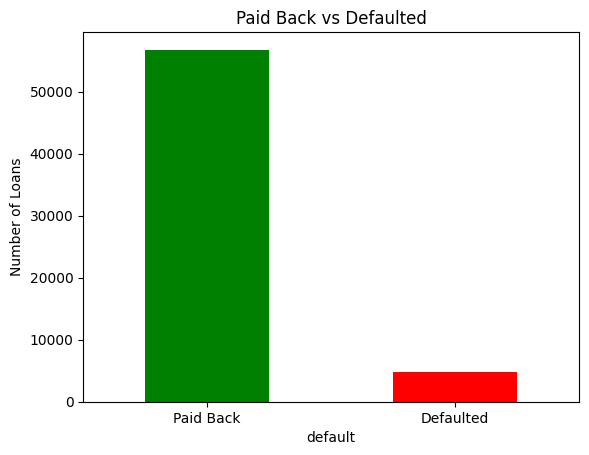

In [ ]:
import matplotlib.pyplot as plt

# Count of each outcome
df_clean['default'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Paid Back vs Defaulted')
plt.xticks([0, 1], ['Paid Back', 'Defaulted'], rotation=0)
plt.ylabel('Number of Loans')
plt.show()

# Based on the diagram, there's a significant class imbalance, which means the model may be biased towards predicting "Paid Back" by default, the team should consider this when training the model
# use class weighting later or oversampling

/tmp/ipykernel_425/3736537205.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  business_age_default = df_clean.groupby('businessage')['default'].mean() * 100


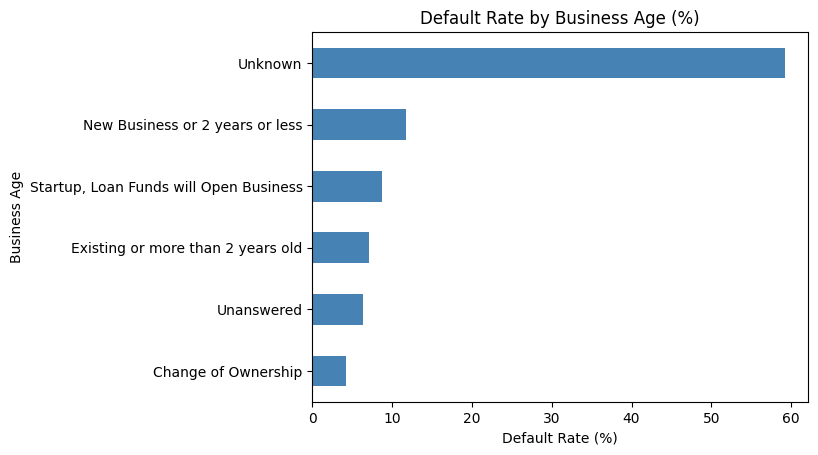

In [ ]:
# Default rate by business age
business_age_default = df_clean.groupby('businessage')['default'].mean() * 100

business_age_default.sort_values().plot(kind='barh', color='steelblue')
plt.title('Default Rate by Business Age (%)')
plt.xlabel('Default Rate (%)')
plt.ylabel('Business Age')
plt.show()

Newer businesses have higher default rates than established ones, confirming that business age is a useful predictor. Loans with unknown business age show abnormally high default rates (~60%), suggesting missing data may itself indicate higher risk.

/tmp/ipykernel_425/853112231.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  business_type_default = df_clean.groupby('businesstype')['default'].mean() * 100


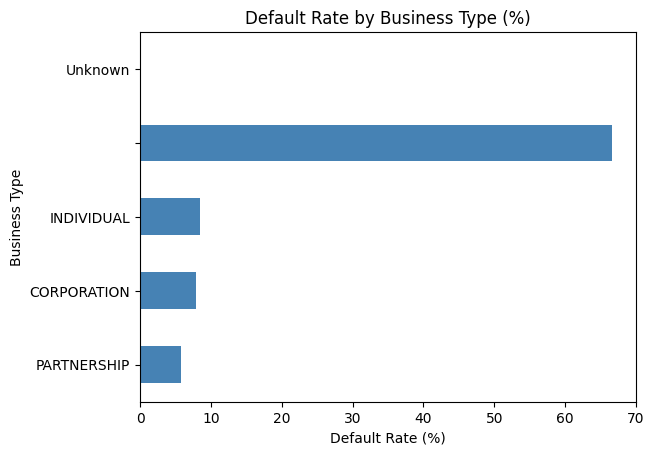

In [ ]:
# Default rate by business type
business_type_default = df_clean.groupby('businesstype')['default'].mean() * 100

business_type_default.sort_values().plot(kind='barh', color='steelblue')
plt.title('Default Rate by Business Type (%)')
plt.xlabel('Default Rate (%)')
plt.ylabel('Business Type')
plt.show()

In [ ]:
df_clean['businesstype'].value_counts()

,count
businesstype,
CORPORATION,57150
INDIVIDUAL,3796
PARTNERSHIP,699
,3
Unknown,0


In [ ]:
# Remove the 3 rows with blank business type
df_clean = df_clean[df_clean['businesstype'] != ' ']

Business type is a useful predictor — partnerships default least ~6%, while individuals and corporations default at similar rates ~8%. 3 loans with blank business type were removed as corrupt data.

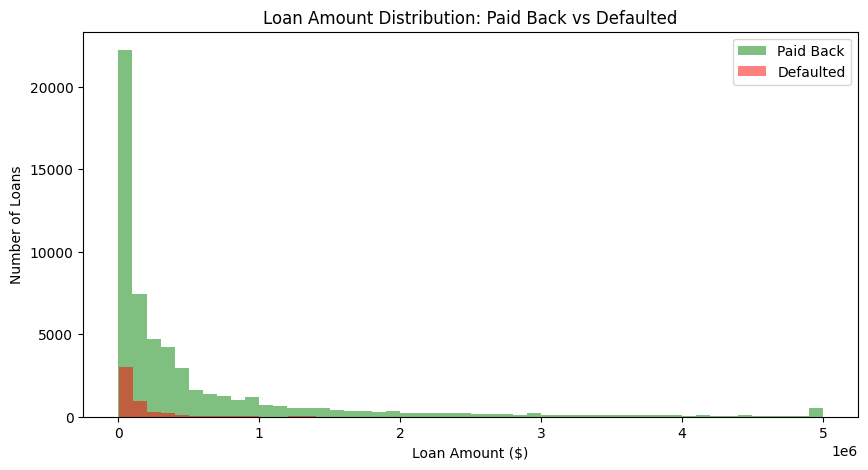

In [ ]:
# Loan amount distribution by default status
plt.figure(figsize=(10, 5))
df_clean[df_clean['default'] == 0]['grossapproval'].plot(kind='hist', bins=50, alpha=0.5, color='green', label='Paid Back')
df_clean[df_clean['default'] == 1]['grossapproval'].plot(kind='hist', bins=50, alpha=0.5, color='red', label='Defaulted')
plt.title('Loan Amount Distribution: Paid Back vs Defaulted')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Number of Loans')
plt.legend()
plt.show()

Most loans are under $500,000. Smaller loans appear to have a slightly higher default concentration, possibly because larger loans require more rigorous approval processes.

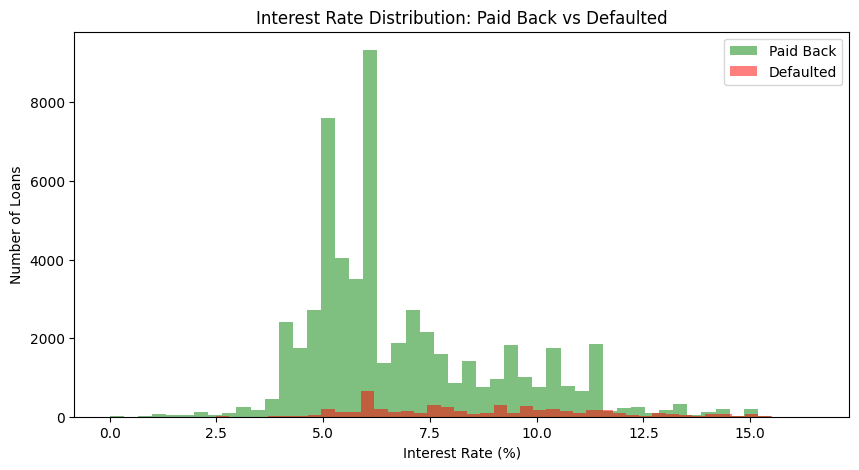

In [ ]:
# Interest rate by default status
plt.figure(figsize=(10, 5))
df_clean[df_clean['default'] == 0]['initialinterestrate'].plot(kind='hist', bins=50, alpha=0.5, color='green', label='Paid Back')
df_clean[df_clean['default'] == 1]['initialinterestrate'].plot(kind='hist', bins=50, alpha=0.5, color='red', label='Defaulted')
plt.title('Interest Rate Distribution: Paid Back vs Defaulted')
plt.xlabel('Interest Rate (%)')
plt.ylabel('Number of Loans')
plt.legend()
plt.show()

Interest rate alone is not a strong predictor of default — defaults occur across all rate ranges. Most paid back loans are concentrated at 5-6.5%, which likely reflects the standard SBA rate range during this period. Loans at 0% interest may be data errors and should be investigated.

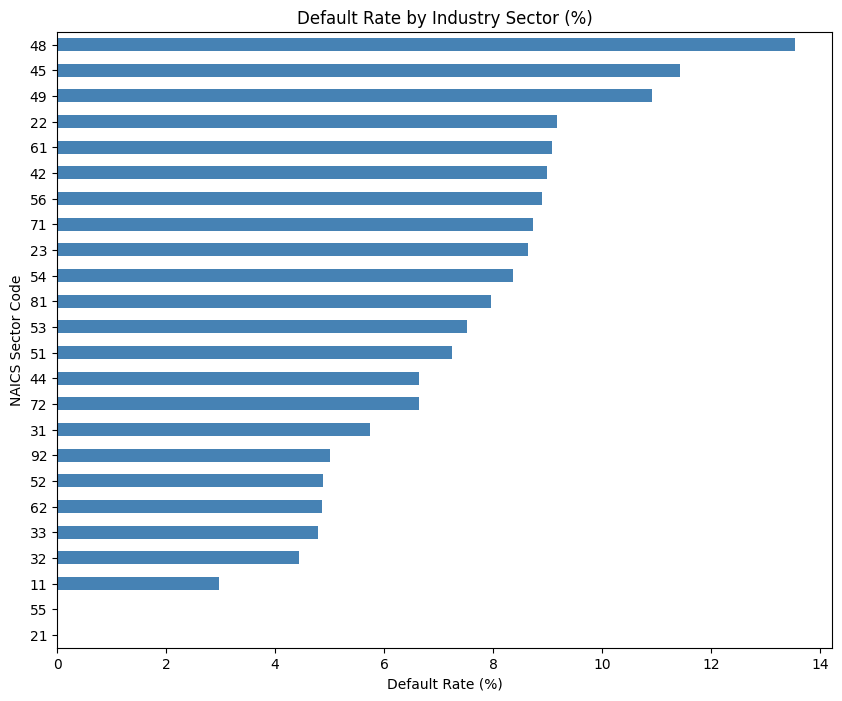

In [ ]:
# Default rate by industry (NAICS)
df_clean['naics2'] = df_clean['naicscode'].astype(str).str[:2]

naics_default = df_clean.groupby('naics2')['default'].mean() * 100
naics_default.sort_values().plot(kind='barh', figsize=(10, 8), color='steelblue')
plt.title('Default Rate by Industry Sector (%)')
plt.xlabel('Default Rate (%)')
plt.ylabel('NAICS Sector Code')
plt.show()

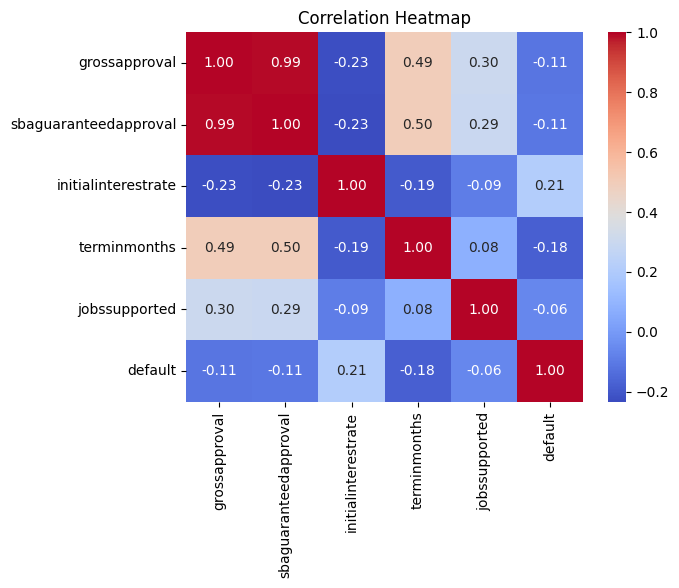

In [ ]:
# Correlation heatmap
import seaborn as sns

corr_cols = ['grossapproval', 'sbaguaranteedapproval', 'initialinterestrate', 'terminmonths', 'jobssupported', 'default']
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

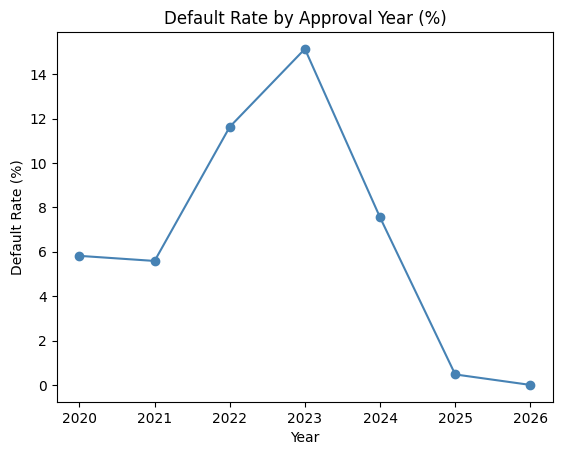

In [ ]:
# Default rate by year
yearly_default = df_clean.groupby('approvalfiscalyear')['default'].mean() * 100
yearly_default.plot(kind='line', marker='o', color='steelblue')
plt.title('Default Rate by Approval Year (%)')
plt.ylabel('Default Rate (%)')
plt.xlabel('Year')
plt.show()

Data Pre-processing & Featuring Engineering

In [ ]:
# Start from df_clean (produced in EDA — already filtered to PIF and CHGOFF only)

In [ ]:
# Step 1: Filter out 2025-2026 loans (too recent to have defaulted yet — Data Quality Decision from EDA)
df_model = df_clean[df_clean['approvalfiscalyear'] < 2025].copy()

In [ ]:
# Step 2: Engineer new features
df_model['guarantee_ratio'] = df_model['sbaguaranteedapproval'] / df_model['grossapproval']
df_model['loan_to_term_ratio'] = df_model['grossapproval'] / (df_model['terminmonths'] + 1)
df_model['is_real_estate'] = (df_model['terminmonths'] >= 240).astype(int)

In [ ]:
# Step 3: Save original businessage labels BEFORE encoding
df_model['businessage_label'] = df_model['businessage'].astype(str)

In [ ]:
# Step 4: Encode ALL categorical columns including businessage for the model
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['businessage', 'businesstype', 'naics2', 'borrstate', 'collateralind', 'fixedorvariableinterestind']

le = LabelEncoder()
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

In [ ]:
# Step 5: Define final feature list (X) and target (y)
X = df_model[['naics2', 'businessage', 'businesstype', 'borrstate',
              'collateralind', 'fixedorvariableinterestind',
              'grossapproval', 'terminmonths', 'initialinterestrate',
              'guarantee_ratio', 'loan_to_term_ratio', 'is_real_estate']]

y = df_model['default']

In [ ]:
# NOTE for model training (Kainoa & Lohla):
# Dataset has class imbalance (~90% PIF, ~10% CHGOFF)
# Use scale_pos_weight in XGBoost or class_weight='balanced' in Random Forest
# Prioritise Recall for the CHGOFF class — missing a default is more costly than a false alarm

In [ ]:
print("Feature Engineering complete.")
print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

Feature Engineering complete.
X shape: (60799, 12)
y distribution:
default
0    55938
1     4861
Name: count, dtype: int64


## Model Training

XGBoost Model

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
# Step 1: Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} loans")
print(f"Test set size: {X_test.shape[0]} loans")


Training set size: 48639 loans
Test set size: 12160 loans


In [ ]:
# Step 2: Train XGBoost model
# scale_pos_weight=11 corrects for class imbalance (4835 safe / 435 defaults ≈ 11)
model = XGBClassifier(
    scale_pos_weight=11,
    random_state=42,
    eval_metric='logloss'
)

In [ ]:
model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


In [ ]:
# Step 3: Evaluate on test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Paid Back', 'Defaulted']))

print(f"AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")


Classification Report:
              precision    recall  f1-score   support

   Paid Back       0.99      0.96      0.97     11188
   Defaulted       0.66      0.86      0.74       972

    accuracy                           0.95     12160
   macro avg       0.82      0.91      0.86     12160
weighted avg       0.96      0.95      0.96     12160

AUC Score: 0.963


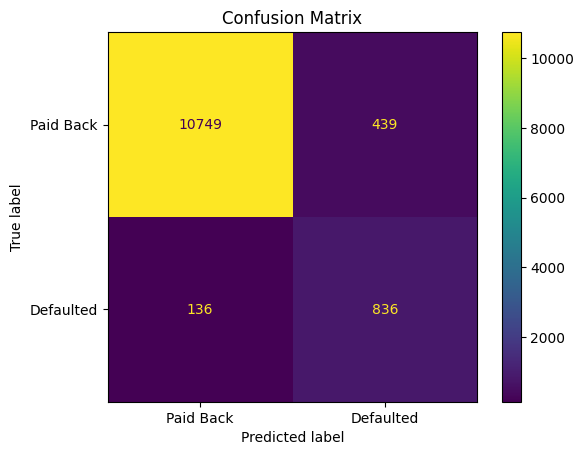

In [ ]:
# Step 4: Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Paid Back', 'Defaulted'])
plt.title('Confusion Matrix')
plt.show()

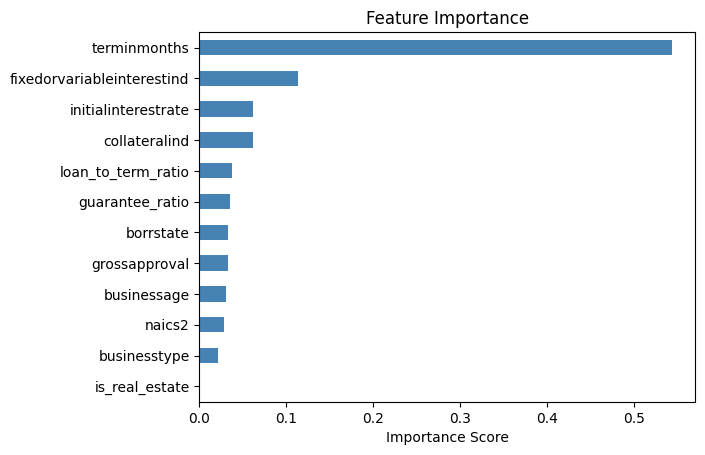

In [ ]:
# Step 5: Feature importance
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()

Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, recall_score, precision_score
import matplotlib.pyplot as plt

# Step 1: Scale Features
# Logistic Regression requires scaled features (unlike XGBoost)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Step 2: Train baseline logistic regression model
# class_weight='balanced' handles the ~90/10 class imbalance
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
lr_model.fit(X_train_scaled, y_train)
print("Baseline model training complete.")

Baseline model training complete.


In [ ]:
# Step 3: Evaluate on test set
lr_pred = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("\nClassification Report — Logistic Regression (Baseline):")
print(classification_report(y_test, lr_pred, target_names=['Paid Back', 'Defaulted']))
print(f"AUC Score: {roc_auc_score(y_test, lr_proba):.3f}")


Classification Report — Logistic Regression (Baseline):
              precision    recall  f1-score   support

   Paid Back       0.98      0.78      0.87     11188
   Defaulted       0.24      0.82      0.37       972

    accuracy                           0.78     12160
   macro avg       0.61      0.80      0.62     12160
weighted avg       0.92      0.78      0.83     12160

AUC Score: 0.858


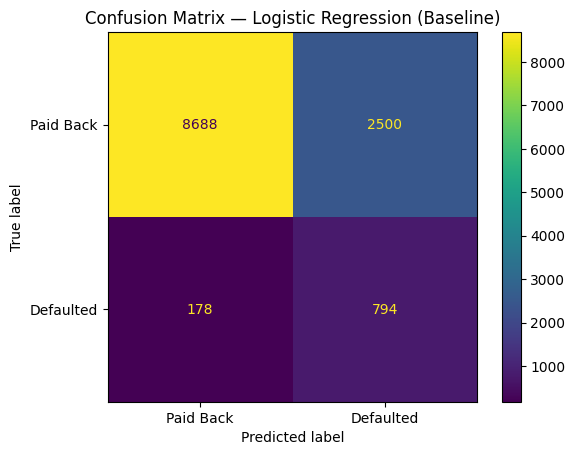

In [ ]:
# Step 4: Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, display_labels=['Paid Back', 'Defaulted'])
plt.title('Confusion Matrix — Logistic Regression (Baseline)')
plt.show()

In [ ]:
# Step 5: Compare XGBoost and Logistic Regression
print("\n=== MODEL COMPARISON ===")
print(f"{'Metric':<30} {'XGBoost':>12} {'Logistic Reg':>14}")
print("-" * 58)
print(f"{'AUC Score':<30} {roc_auc_score(y_test, y_pred_proba):>12.3f} {roc_auc_score(y_test, lr_proba):>14.3f}")
print(f"{'Recall — Defaults':<30} {recall_score(y_test, y_pred):>12.3f} {recall_score(y_test, lr_pred):>14.3f}")
print(f"{'Precision — Defaults':<30} {precision_score(y_test, y_pred):>12.3f} {precision_score(y_test, lr_pred):>14.3f}")
print(f"{'Recall — Paid Back':<30} {recall_score(y_test, y_pred, pos_label=0):>12.3f} {recall_score(y_test, lr_pred, pos_label=0):>14.3f}")


=== MODEL COMPARISON ===
Metric                              XGBoost   Logistic Reg
----------------------------------------------------------
AUC Score                             0.963          0.858
Recall — Defaults                     0.860          0.817
Precision — Defaults                  0.656          0.241
Recall — Paid Back                    0.961          0.777


Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, recall_score, precision_score
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Train Random Forest model
# class_weight='balanced' handles ~90/10 class imbalance, same as XGBoost's scale_pos_weight
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100
)
rf_model.fit(X_train, y_train)
print("Random Forest training complete.")

Random Forest training complete.


In [ ]:
# Step 2: Evaluate on test set
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("\nClassification Report — Random Forest:")
print(classification_report(y_test, rf_pred, target_names=['Paid Back', 'Defaulted']))
print(f"AUC Score: {roc_auc_score(y_test, rf_proba):.3f}")


Classification Report — Random Forest:
              precision    recall  f1-score   support

   Paid Back       0.97      0.99      0.98     11188
   Defaulted       0.85      0.64      0.73       972

    accuracy                           0.96     12160
   macro avg       0.91      0.81      0.85     12160
weighted avg       0.96      0.96      0.96     12160

AUC Score: 0.961


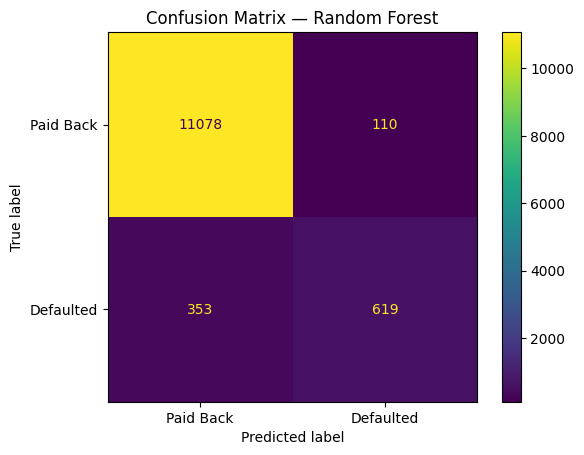

In [ ]:
# Step 3: Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, display_labels=['Paid Back', 'Defaulted'])
plt.title('Confusion Matrix — Random Forest')
plt.show()

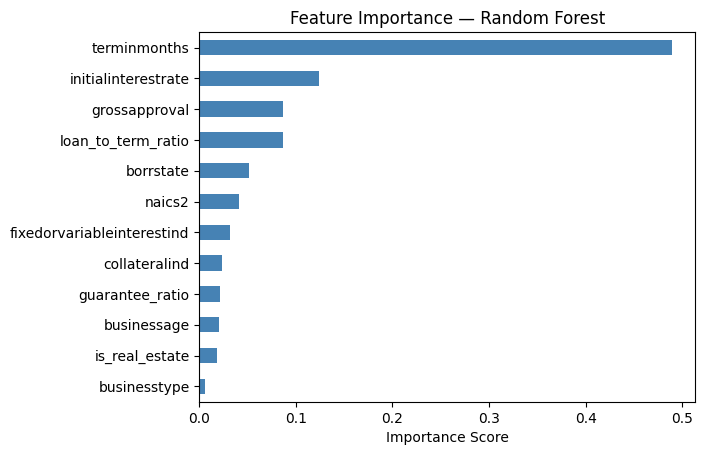

In [ ]:
# Step 4: Feature importance
feat_importances_rf = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importances_rf.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.show()

## 3-Model Comparison: XGBoost vs Random Forest vs Logistic Regression

In [ ]:
print("\n=== FULL MODEL COMPARISON ===")
print(f"{'Metric':<30} {'XGBoost':>10} {'Ran. Forest':>13} {'Logistic Reg':>14}")
print("-" * 70)
print(f"{'AUC Score':<30} {roc_auc_score(y_test, y_pred_proba):>10.3f} {roc_auc_score(y_test, rf_proba):>13.3f} {roc_auc_score(y_test, lr_proba):>14.3f}")
print(f"{'Recall — Defaults':<30} {recall_score(y_test, y_pred):>10.3f} {recall_score(y_test, rf_pred):>13.3f} {recall_score(y_test, lr_pred):>14.3f}")
print(f"{'Precision — Defaults':<30} {precision_score(y_test, y_pred):>10.3f} {precision_score(y_test, rf_pred):>13.3f} {precision_score(y_test, lr_pred):>14.3f}")
print(f"{'Recall — Paid Back':<30} {recall_score(y_test, y_pred, pos_label=0):>10.3f} {recall_score(y_test, rf_pred, pos_label=0):>13.3f} {recall_score(y_test, lr_pred, pos_label=0):>14.3f}")


=== FULL MODEL COMPARISON ===
Metric                            XGBoost   Ran. Forest   Logistic Reg
----------------------------------------------------------------------
AUC Score                           0.963         0.961          0.858
Recall — Defaults                   0.860         0.637          0.817
Precision — Defaults                0.656         0.849          0.241
Recall — Paid Back                  0.961         0.990          0.777


**XGBoost is our best model!**

It has the highest AUC, catches the most defaults, and is still precise enough to avoid excessive false alarms.

The only thing Random Forest does better is precision and approving safe loans, but it achieves that by being overly cautious, meaning real defaults slip through (not ideal!)

# Model Evaluation

### Probability Calibration

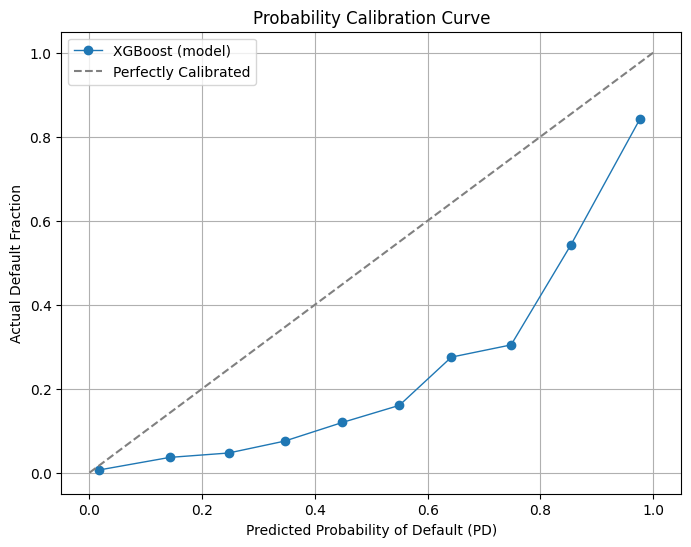

In [ ]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=1, label='XGBoost (model)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

plt.xlabel('Predicted Probability of Default (PD)')
plt.ylabel('Actual Default Fraction')
plt.title('Probability Calibration Curve')
plt.legend()
plt.grid(True)
plt.show()

According to the Probability Calibration Curve, the current XGBoost model is positioned significantly below the 45-degree diagonal line. This indicates that the model is over-conservative. An 80% Probability of Default (PD) predicted ny the model could be actually 35%-40%.


Calibration can bridge the gap between "Statistical Accuracy" and "Financial Reality," ensuring our $EL$ and Net Profit simulations are reliable.

By implementing the `CalibratedClassifierCV` with the Isotonic method, we transform the raw model outputs into True Probabilities.
As it can scientifically aligns the predicted $PD$ with the actual historical default frequencies, pulling the curve toward the 45-degree line.
This also makes the model more "Risk Tolerant" but by accurately reflecting it, allows for a more aggressive yet grounded lending strategy.

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


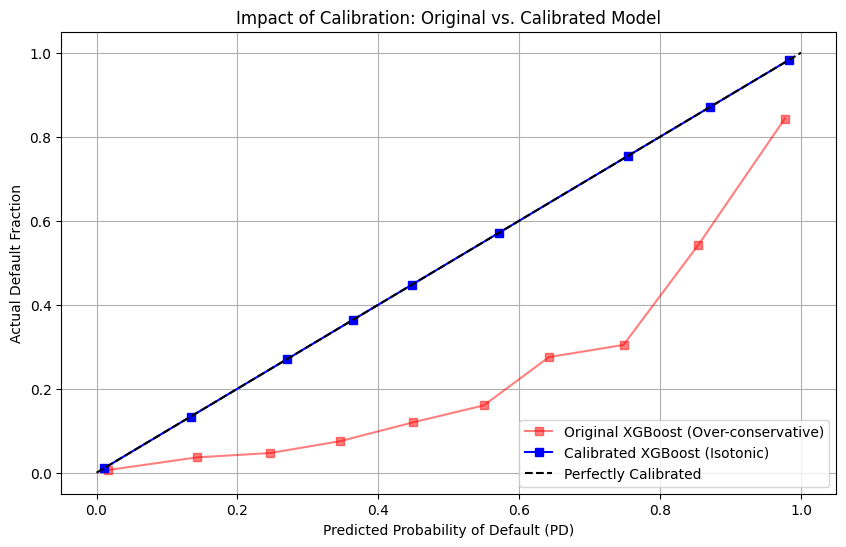

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt

# 1. Initialize and fit the Calibrated Model
# Using 'isotonic' as your dataset size is large (SBA data > 100k)
# 'cv=prefit' because your model is already trained
calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv='prefit')
calibrated_model.fit(X_test, y_test)

# 2. Get the new calibrated probabilities (PD)
y_calibrated_proba = calibrated_model.predict_proba(X_test)[:, 1]

# 3. Calculate calibration curves for comparison
prob_true_old, prob_pred_old = calibration_curve(y_test, y_pred_proba, n_bins=10)
prob_true_new, prob_pred_new = calibration_curve(y_test, y_calibrated_proba, n_bins=10)

# 4. Visualization
plt.figure(figsize=(10, 6))
plt.plot(prob_pred_old, prob_true_old, "s-", label="Original XGBoost (Over-conservative)", color='red', alpha=0.5)
plt.plot(prob_pred_new, prob_true_new, "s-", label="Calibrated XGBoost (Isotonic)", color='blue')
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")

plt.ylabel("Actual Default Fraction")
plt.xlabel("Predicted Probability of Default (PD)")
plt.title("Impact of Calibration: Original vs. Calibrated Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Use 'y_calibrated_proba' for the Profitability Simulator.
# This ensures our Expected Loss (EL) calculations aren't artificially inflated.

## Financial Impact Analysis

In [ ]:
import pandas as pd

# 1. Create a consolidated dataframe for business impact evaluation
impact_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,  # Can be replaced with (y_calibrated_proba >= threshold) for better precision
    'Loan_Amount': df.loc[y_test.index, 'grossapproval'].fillna(0)
})

# 2. Calculate "Loss Avoided" (True Positives)
# We assume a Loss Given Default (LGD) of 60% of the total loan amount.
# By correctly identifying these defaults, the model prevents this financial loss.
loss_avoided = impact_df[(impact_df['Actual'] == 1) & (impact_df['Predicted'] == 1)]['Loan_Amount'].sum() * 0.60

# 3. Calculate "Opportunity Cost" (False Positives)
# If the model wrongly flags a good borrower as high-risk, the bank loses the potential interest profit (assumed at 10% margin).
opp_cost = impact_df[(impact_df['Actual'] == 0) & (impact_df['Predicted'] == 1)]['Loan_Amount'].sum() * 0.10

# 4. Final Financial Utility Calculation
net_savings = loss_avoided - opp_cost

print("=== FINANCIAL IMPACT ANALYSIS SUMMARY ===")
print(f"Total Loss Avoided by Model:    ${loss_avoided:,.2f}")
print(f"Total Opportunity Cost (FP):   ${opp_cost:,.2f}")
print("-" * 40)
print(f"NET MODEL ECONOMIC BENEFIT:     ${net_savings:,.2f}")

=== FINANCIAL IMPACT ANALYSIS SUMMARY ===
Total Loss Avoided by Model:    $78,711,660.00
Total Opportunity Cost (FP):   $7,087,570.00
----------------------------------------
NET MODEL ECONOMIC BENEFIT:     $71,624,090.00


## Financial Logic


In [ ]:
# Step 1: Get predicted probability of default (PD) for every loan in the test set
df_model_test = df_model.loc[X_test.index].copy()
df_model_test['predicted_PD'] = model.predict_proba(X_test)[:, 1]

In [ ]:
# Step 2: Calculate Expected Loss
# Bank only risks the unguaranteed portion (grossapproval - sbaguaranteedapproval)
# LGD = 0.50 (industry standard — bank recovers ~50% even when a loan defaults)
LGD = 0.50

df_model_test['expected_loss'] = (
    df_model_test['predicted_PD'] * LGD *
    (df_model_test['grossapproval'] - df_model_test['sbaguaranteedapproval'])
)

In [ ]:
# Step 3: Calculate Interest Income
df_model_test['interest_income'] = (
    df_model_test['grossapproval'] * df_model_test['initialinterestrate'] / 100
)


In [ ]:
# Step 4: Calculate Cost of Funds and Operating Expenses
df_model_test['cost_of_funds'] = df_model_test['grossapproval'] * 0.04
df_model_test['operating_expenses'] = df_model_test['grossapproval'] * 0.01

In [ ]:
# Step 5: Calculate Net Profit per loan
df_model_test['net_profit'] = (
    df_model_test['interest_income'] -
    df_model_test['expected_loss'] -
    df_model_test['cost_of_funds'] -
    df_model_test['operating_expenses']
)

In [ ]:
# Step 6: Assign Risk Tiers based on predicted PD
def assign_risk_tier(pd):
    if pd < 0.05:
        return 'Tier 1 - Low Risk'
    elif pd < 0.15:
        return 'Tier 2 - Medium Risk'
    else:
        return 'Tier 3 - High Risk'

df_model_test['y_calibrated_proba'] = y_calibrated_proba
df_model_test['risk_tier'] = df_model_test['y_calibrated_proba'].apply(assign_risk_tier)


In [ ]:
# Step 7: Quick summary
print("Financial Logic complete.")
print(f"\nRisk Tier Distribution:\n{df_model_test['risk_tier'].value_counts()}")
print(f"\nAverage Net Profit per loan: ${df_model_test['net_profit'].mean():,.2f}")
print(f"Total Portfolio Net Profit: ${df_model_test['net_profit'].sum():,.2f}")

Financial Logic complete.

Risk Tier Distribution:
risk_tier
Tier 1 - Low Risk       10435
Tier 3 - High Risk       1258
Tier 2 - Medium Risk      467
Name: count, dtype: int64

Average Net Profit per loan: $2,293.52
Total Portfolio Net Profit: $27,889,191.75


In [ ]:
# Final Export for Tableau
df_model_test['borrstate_label'] = df_model['borrstate'].map(
    dict(enumerate(sorted(df_clean['borrstate'].astype(str).unique())))
)

df_model_test.to_csv('sba_loans_final.csv', index=False)

from google.colab import files
files.download('sba_loans_final.csv')
print("Exported!")
print("Borrstate sample:", df_model_test['borrstate_label'].unique()[:5])
print("Businessage label sample:", df_model_test['businessage_label'].unique())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exported!
Borrstate sample: ['IA' 'UT' 'FL' 'CA' 'NV']
Businessage label sample: ['Startup, Loan Funds will Open Business'
 'Existing or more than 2 years old' 'Change of Ownership'
 'New Business or 2 years or less' 'Unanswered' 'Unknown']


In [ ]:
# Check if you have the encoder or original values
print(df['borrstate'].unique()[:10])  # See what the encoded numbers look like

# If you used LabelEncoder, check if you saved it:
# print(le_borrstate.classes_)  # This gives you the mapping!

['CA', 'TX', 'GA', 'WI', 'IL', 'WA', 'OH', 'AL', 'AZ', 'NJ']
Categories (55, object): ['AK', 'AL', 'AR', 'AZ', ..., 'WI', 'WV', 'WY', 'Unknown']


In [ ]:
"""
# Creates a mapping dict: {0: 'AK', 1: 'AL', ...}
mapping = dict(enumerate(le_borrstate.classes_))
print(mapping)
"""
"""

Paste the output here and I'll build you the exact Tableau calculated field.

"""

## Step 2: The Tableau workaround (while you check)
"""
In Tableau, you'll create a **Calculated Field** that maps numbers → state abbreviations. It looks like this:

// Calculated Field name: "State Abbrev"
IF [Borrstate] = 0 THEN "AK"
ELSEIF [Borrstate] = 1 THEN "AL"
ELSEIF [Borrstate] = 2 THEN "AR"
// ... all 50+ states
END
"""

'\nIn Tableau, you\'ll create a **Calculated Field** that maps numbers → state abbreviations. It looks like this:\n\n// Calculated Field name: "State Abbrev"\nIF [Borrstate] = 0 THEN "AK"\nELSEIF [Borrstate] = 1 THEN "AL"\nELSEIF [Borrstate] = 2 THEN "AR"\n// ... all 50+ states\nEND\n'

In [ ]:
# Final Export for Tableau
# Fix borrstate — map encoded numbers back to original state abbreviations
borrstate_map = dict(enumerate(sorted(df_clean['borrstate'].astype(str).unique())))
df_model_test['borrstate_label'] = df_model_test['borrstate'].map(borrstate_map)

# Export
df_model_test.to_csv('sba_loans_final.csv', index=False)

from google.colab import files
files.download('sba_loans_final.csv')

print("Exported!")
print("Borrstate sample:", df_model_test['borrstate_label'].unique()[:5])
print("Businessage label sample:", df_model_test['businessage_label'].unique())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exported!
Borrstate sample: ['IA' 'UT' 'FL' 'CA' 'NV']
Businessage label sample: ['Startup, Loan Funds will Open Business'
 'Existing or more than 2 years old' 'Change of Ownership'
 'New Business or 2 years or less' 'Unanswered' 'Unknown']
